In [5]:
import numpy as np
import pandas as pd

In [6]:
# Load diabetes dataset
df = pd.read_csv("D:\BDA_0024\AML_LAB\project_LAB_4\data\diabetes.csv")

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [7]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [9]:
df.shape

(768, 9)

In [10]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [11]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [12]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [13]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [14]:
# Check missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [15]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [16]:
# Check target distribution
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [17]:
# Check target percentages
df["Outcome"].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

In [18]:
# Replace invalid zeros with NaN
cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[cols] = df[cols].replace(0, np.nan)

In [19]:
# Check missing values after cleaning
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [37]:
# Import imputer
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

In [21]:
# Separate input and target
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [22]:
# Check shapes
print("X shape:", x.shape)
print("Y shape:", y.shape)

X shape: (768, 8)
Y shape: (768,)


In [23]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=45,
    stratify=y
)

In [24]:
# Fill missing values using training mean
imputer = SimpleImputer(strategy="mean")

x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [25]:
# Check missing values after imputation
print("Training missing values:", np.isnan(x_train).sum())
print("Testing missing values:", np.isnan(x_test).sum())

Training missing values: 0
Testing missing values: 0


In [26]:
from sklearn.preprocessing import StandardScaler

sc_x = StandardScaler()

x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)

***Decision Tree Classifier with Entropy***

In [27]:
# Create Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(
    criterion="entropy",
    random_state=0
)

In [28]:
# Train the model
classifier.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [29]:
# Predict test data
y_pred = classifier.predict(x_test)

y_pred

array([1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1])

In [30]:
# Compare actual and predicted values
print("Actual:", y_test)
print("Predicted:", y_pred)

Actual: [1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1
 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 1 1 1 0 1 0
 1 0 0 0 0 1 1 0 1 1 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 1 0
 1 1 0 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0
 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 0 0 1 1 1 0 1 1 1 0 1 1 0 1 0 1 0 0 0 0 0 0
 0 0 1 0 0 0 0]
Predicted: [1 0 1 0 1 0 0 1 0 0 1 0 1 0 0 1 0 0 1 1 0 0 0 1 1 0 1 1 0 0 0 0 0 1 1 0 1
 0 0 0 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 1 0 0 1 0 1 1 1 0 0 0
 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0
 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 1 0 1 1 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 0 1 0 0 1 1 1 1 1 1 0 0 0 0 1 0
 0 0 1 0 0 0 1]


In [31]:
# Calculate accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7395833333333334


In [32]:
# Display confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[100  25]
 [ 25  42]]


In [33]:
# Display classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80       125
           1       0.63      0.63      0.63        67

    accuracy                           0.74       192
   macro avg       0.71      0.71      0.71       192
weighted avg       0.74      0.74      0.74       192



[Text(0.47650462962962964, 0.975, 'x[1] <= 0.159\nentropy = 0.933\nsamples = 576\nvalue = [375, 201]'),
 Text(0.19907407407407407, 0.925, 'x[7] <= -0.395\nentropy = 0.719\nsamples = 363\nvalue = [291, 72]'),
 Text(0.3377893518518519, 0.95, 'True  '),
 Text(0.1037037037037037, 0.875, 'x[5] <= 1.907\nentropy = 0.415\nsamples = 203\nvalue = [186, 17]'),
 Text(0.08888888888888889, 0.825, 'x[5] <= -0.183\nentropy = 0.366\nsamples = 200\nvalue = [186.0, 14.0]'),
 Text(0.05925925925925926, 0.775, 'x[0] <= 0.971\nentropy = 0.13\nsamples = 111\nvalue = [109, 2]'),
 Text(0.044444444444444446, 0.725, 'x[4] <= -1.237\nentropy = 0.075\nsamples = 110\nvalue = [109, 1]'),
 Text(0.02962962962962963, 0.675, 'x[6] <= 0.428\nentropy = 0.391\nsamples = 13\nvalue = [12, 1]'),
 Text(0.014814814814814815, 0.625, 'entropy = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.044444444444444446, 0.625, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.05925925925925926, 0.675, 'entropy = 0.0\nsamples = 97\nvalu

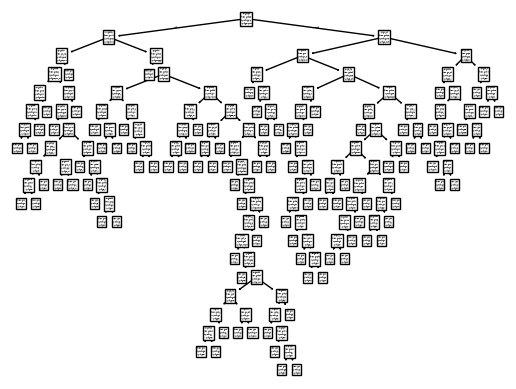

In [34]:
from sklearn import tree
tree.plot_tree(classifier)

***APPLYING K_FOLD CROSS VALIDATION FOR THE SAME DATASET***

In [35]:
# Import StratifiedKFold for cross-validation
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [39]:
# Create 5-fold stratified cross-validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [40]:
# Create a new Decision Tree classifier for cross-validation
cv_classifier = DecisionTreeClassifier(
    criterion="entropy",
    random_state=0
)

In [41]:
# Perform 5-fold cross-validation using accuracy
cv_accuracy = cross_val_score(
    cv_classifier,
    x,
    y,
    cv=skf,
    scoring="accuracy"
)

print("Accuracy for each fold:")
print(cv_accuracy)

print("\nMean Cross-Validation Accuracy:")
print(cv_accuracy.mean())

Accuracy for each fold:
[0.68831169 0.71428571 0.7012987  0.74509804 0.60784314]

Mean Cross-Validation Accuracy:
0.6913674560733385


In [42]:
# Calculate precision for each fold
cv_precision = cross_val_score(
    cv_classifier,
    x,
    y,
    cv=skf,
    scoring="precision"
)

print("Precision for each fold:")
print(cv_precision)

print("\nMean Precision:")
print(cv_precision.mean())

Precision for each fold:
[0.55769231 0.60416667 0.57407407 0.625      0.44262295]

Mean Precision:
0.5607111998505441


In [43]:
# Calculate recall for each fold
cv_recall = cross_val_score(
    cv_classifier,
    x,
    y,
    cv=skf,
    scoring="recall"
)

print("Recall for each fold:")
print(cv_recall)

print("\nMean Recall:")
print(cv_recall.mean())

Recall for each fold:
[0.53703704 0.53703704 0.57407407 0.66037736 0.50943396]

Mean Recall:
0.5635918937805731


In [44]:
# Calculate F1 score for each fold
cv_f1 = cross_val_score(
    cv_classifier,
    x,
    y,
    cv=skf,
    scoring="f1"
)

print("F1 Score for each fold:")
print(cv_f1)

print("\nMean F1 Score:")
print(cv_f1.mean())

F1 Score for each fold:
[0.54716981 0.56862745 0.57407407 0.64220183 0.47368421]

Mean F1 Score:
0.5611514763527844


In [45]:
# Calculate the average performance across all 5 folds
mean_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    
    "Mean Score": [
        cv_accuracy.mean(),
        cv_precision.mean(),
        cv_recall.mean(),
        cv_f1.mean()
    ]
})

mean_results

,Metric,Mean Score
0,Accuracy,0.691367
1,Precision,0.560711
2,Recall,0.563592
3,F1 Score,0.561151


In [46]:
# Calculate standard deviation to measure variation between folds

print("Accuracy Mean:", cv_accuracy.mean())
print("Accuracy Std:", cv_accuracy.std())

print("\nPrecision Mean:", cv_precision.mean())
print("Precision Std:", cv_precision.std())

print("\nRecall Mean:", cv_recall.mean())
print("Recall Std:", cv_recall.std())

print("\nF1 Score Mean:", cv_f1.mean())
print("F1 Score Std:", cv_f1.std())

Accuracy Mean: 0.6913674560733385
Accuracy Std: 0.04581812153881726

Precision Mean: 0.5607111998505441
Precision Std: 0.0634884904489278

Recall Mean: 0.5635918937805731
Recall Std: 0.052575098026179

F1 Score Mean: 0.5611514763527844
F1 Score Std: 0.054107400401903934


In [47]:
# Compare the original train-test split accuracy
# with the mean 5-fold cross-validation accuracy

print("Original Test Accuracy:", accuracy)
print("Mean 5-Fold CV Accuracy:", cv_accuracy.mean())

Original Test Accuracy: 0.7395833333333334
Mean 5-Fold CV Accuracy: 0.6913674560733385
